# Dynamischen Verluste


🔧 Analyse: Nexperia


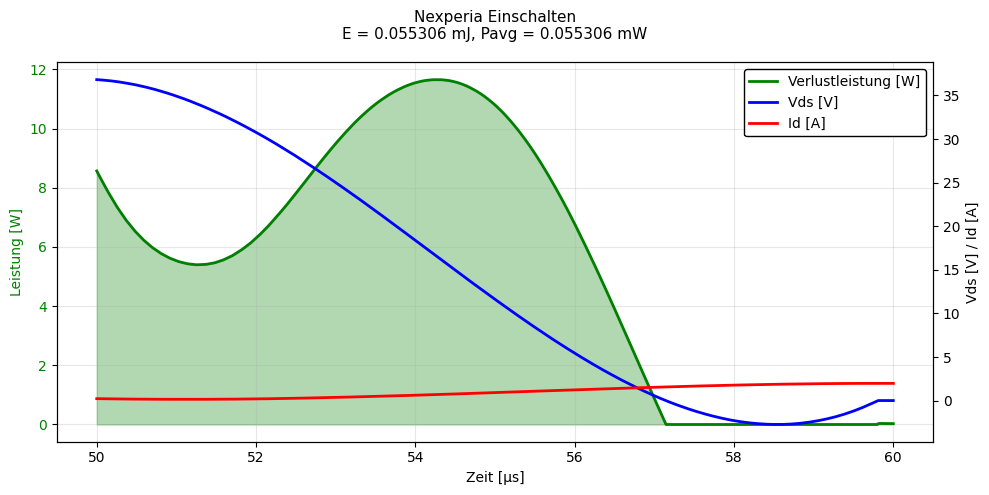

  🔹 Einschalten: 0.055306 mJ, 0.055306 mW


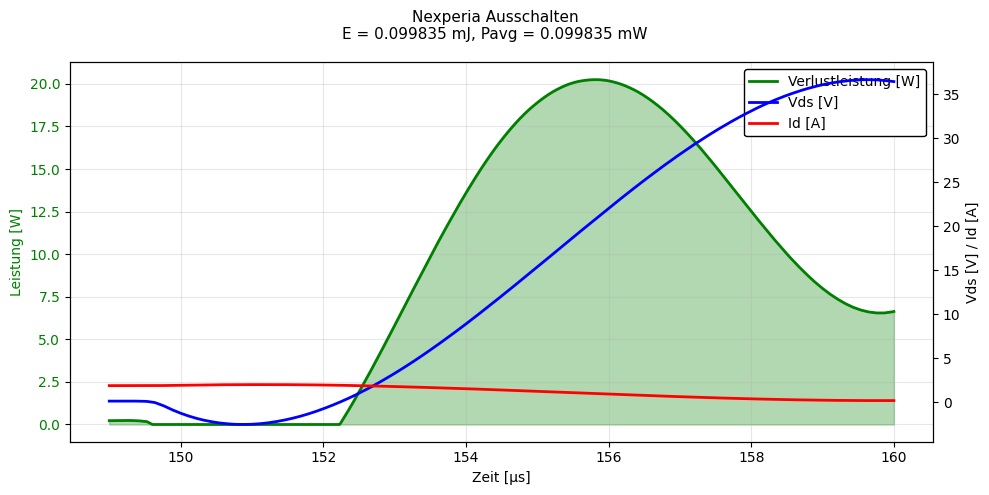

  🔹 Ausschalten: 0.099835 mJ, 0.099835 mW
  ✅ Gesamt: 0.155141 mJ, 0.155141 mW

🔧 Analyse: Vishay


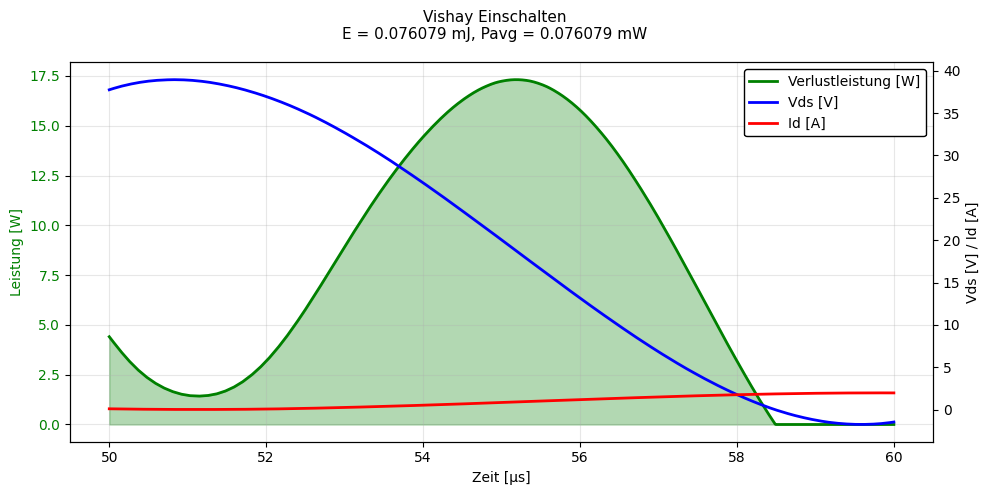

  🔹 Einschalten: 0.076079 mJ, 0.076079 mW


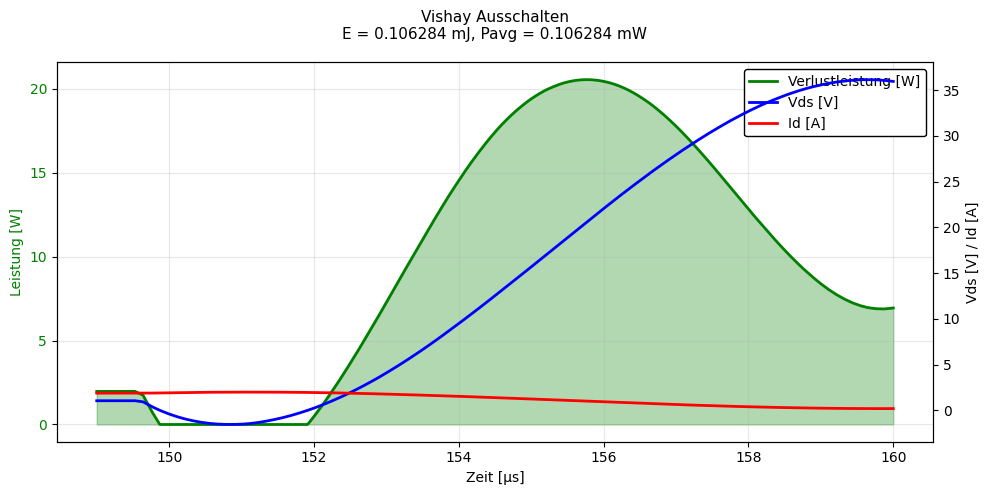

  🔹 Ausschalten: 0.106284 mJ, 0.106284 mW
  ✅ Gesamt: 0.182363 mJ, 0.182363 mW


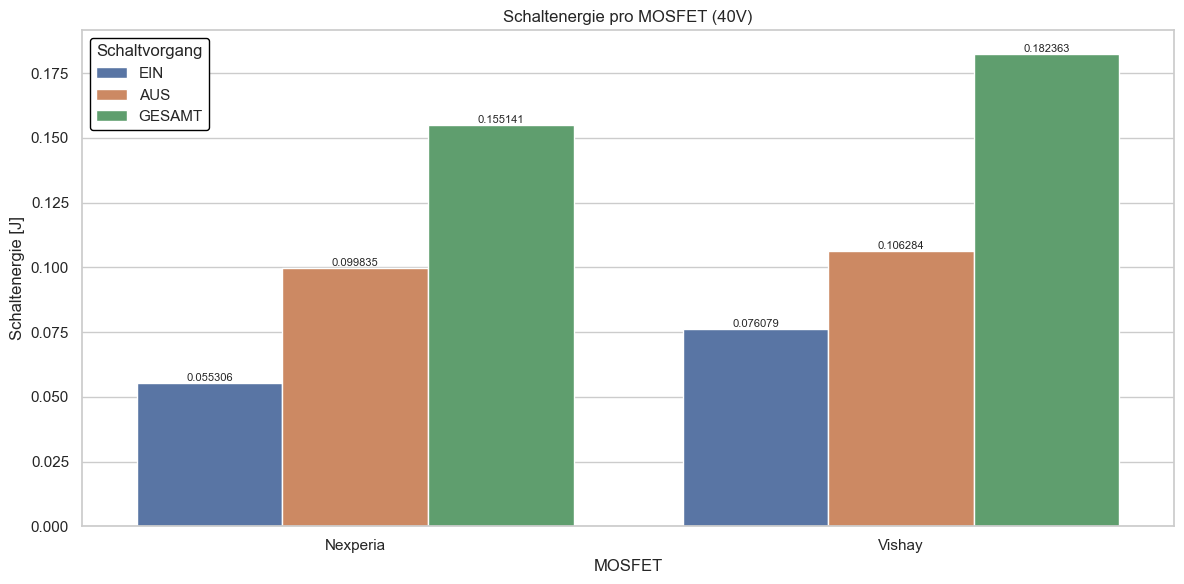

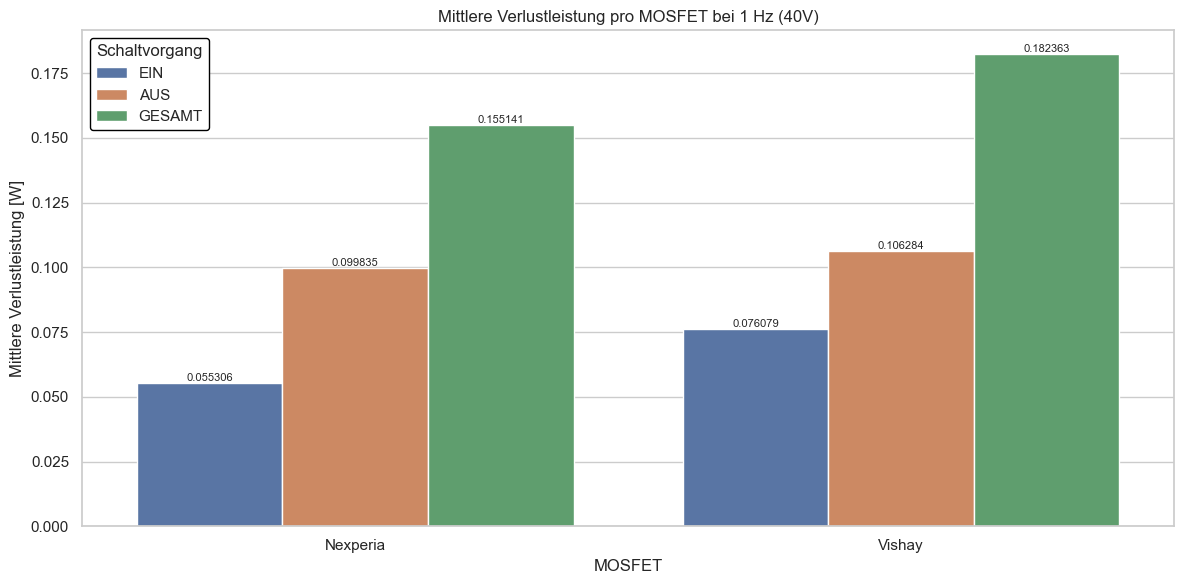

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# ⚙️ Einstellungen
DATA_DIR = "./Messwertebearbeitet/40V"  # Ordner enthält z.B. "C1Infineon.txt"
ON_START, ON_END = 50, 60               # µs
OFF_START, OFF_END = 149, 160           # µs
SWITCH_FREQ_HZ = 1                      # z. B. 100 kHz → 100_000

# 🔄 Hilfsfunktion: Lade und benenne Spalten korrekt
def load_data(filepath):
    df = pd.read_csv(filepath)
    df.columns = [col.strip() for col in df.columns]
    if "Amplitude" in df.columns:
        df = df.rename(columns={"Amplitude": "Ampl"})
    df["Time_us"] = df["Time"] * 1e6
    return df

# 🔍 Schaltverluste berechnen & grafisch anzeigen
def calculate_and_plot_loss(df_vds, df_id, start_us, end_us, mosfet_name, mode):
    interp_vds = interp1d(df_vds["Time_us"], df_vds["Ampl"], kind="linear", fill_value="extrapolate")
    interp_id = interp1d(df_id["Time_us"], df_id["Ampl"], kind="linear", fill_value="extrapolate")
    time_common = np.linspace(start_us, end_us, 1000)
    vds_vals = interp_vds(time_common)
    id_vals = interp_id(time_common)
    power_vals = vds_vals * id_vals
    power_vals[power_vals < 0] = 0

    energy_joule = np.trapezoid(power_vals, time_common) * 1e-6
    power_avg_watt = energy_joule * SWITCH_FREQ_HZ

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(time_common, power_vals, label="Verlustleistung [W]", color="green", linewidth=2, linestyle='-')
    ax1.fill_between(time_common, power_vals, alpha=0.3, color="green")
    ax1.set_xlabel("Zeit [µs]")
    ax1.set_ylabel("Leistung [W]", color="green")
    ax1.tick_params(axis='y', labelcolor="green")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(time_common, vds_vals, label="Vds [V]", color="blue", linewidth=2, linestyle='-')
    ax2.plot(time_common, id_vals, label="Id [A]", color="red", linewidth=2, linestyle='-')
    ax2.set_ylabel("Vds [V] / Id [A]", color="black")
    ax2.tick_params(axis='y', labelcolor="black")

    title_clean = f"{mosfet_name} {mode}"
    fig.suptitle(f"{title_clean}\nE = {energy_joule*1e3:.6f} mJ, Pavg = {power_avg_watt*1e3:.6f} mW", fontsize=11)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10, frameon=True, framealpha=1, edgecolor="black")

    plt.tight_layout()
    plt.show()

    return energy_joule, power_avg_watt

# 🧾 Ergebnisliste
results = []

# 📂 Dateinamen durchgehen
files_c1 = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("C1")])

for file_c1 in files_c1:
    mosfet_name = file_c1[2:].replace(".txt", "")  # z. B. "Infineon"
    file_c2 = f"C2{mosfet_name}.txt"
    path_c1 = os.path.join(DATA_DIR, file_c1)
    path_c2 = os.path.join(DATA_DIR, file_c2)

    if not os.path.exists(path_c2):
        print(f"⚠️  Keine passende Datei für {mosfet_name}, überspringe.")
        continue

    print(f"\n🔧 Analyse: {mosfet_name}")
    df_vds = load_data(path_c1)
    df_id = load_data(path_c2)

    e_on, p_on = calculate_and_plot_loss(df_vds, df_id, ON_START, ON_END, mosfet_name, "Einschalten")
    print(f"  🔹 Einschalten: {e_on*1e3:.6f} mJ, {p_on*1e3:.6f} mW")

    e_off, p_off = calculate_and_plot_loss(df_vds, df_id, OFF_START, OFF_END, mosfet_name, "Ausschalten")
    print(f"  🔹 Ausschalten: {e_off*1e3:.6f} mJ, {p_off*1e3:.6f} mW")

    e_total = e_on + e_off
    p_total = p_on + p_off
    print(f"  ✅ Gesamt: {e_total*1e3:.6f} mJ, {p_total*1e3:.6f} mW")

    results.extend([
        {"MOSFET": mosfet_name, "Typ": "EIN", "Energie_mJ": round(e_on * 1e3, 6), "Leistung_mW": round(p_on * 1e3, 6)},
        {"MOSFET": mosfet_name, "Typ": "AUS", "Energie_mJ": round(e_off * 1e3, 6), "Leistung_mW": round(p_off * 1e3, 6)},
        {"MOSFET": mosfet_name, "Typ": "GESAMT", "Energie_mJ": round(e_total * 1e3, 6), "Leistung_mW": round(p_total * 1e3, 6)}
    ])

# 📊 Zusammenfassung als DataFrame
df_results = pd.DataFrame(results)
spannung = os.path.basename(DATA_DIR)  # z. B. "40V"

# 📈 Säulendiagramm: Energie
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=df_results, x="MOSFET", y="Energie_mJ", hue="Typ")
plt.ylabel("Schaltenergie [J]")
plt.title(f"Schaltenergie pro MOSFET ({spannung})")
plt.legend(title="Schaltvorgang", frameon=True, framealpha=1, edgecolor="black")

# ➕ Werte auf Balken anzeigen (horizontal!)
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.6f", label_type="edge", fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

# 📈 Säulendiagramm: Durchschnittsleistung
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=df_results, x="MOSFET", y="Leistung_mW", hue="Typ")
plt.ylabel("Mittlere Verlustleistung [W]")
plt.title(f"Mittlere Verlustleistung pro MOSFET bei {SWITCH_FREQ_HZ} Hz ({spannung})")
plt.legend(title="Schaltvorgang", frameon=True, framealpha=1, edgecolor="black")

# ➕ Werte auf Balken anzeigen (horizontal!)
for container in barplot.containers:
    barplot.bar_label(container, fmt="%.6f", label_type="edge", fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

# Statischen Verluste


🔧 Analyse statische Verluste (MOSFET AUS): Nexperia


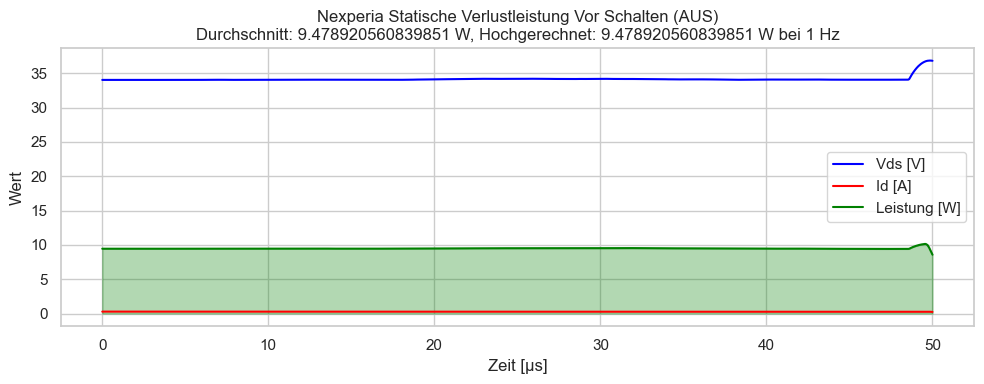

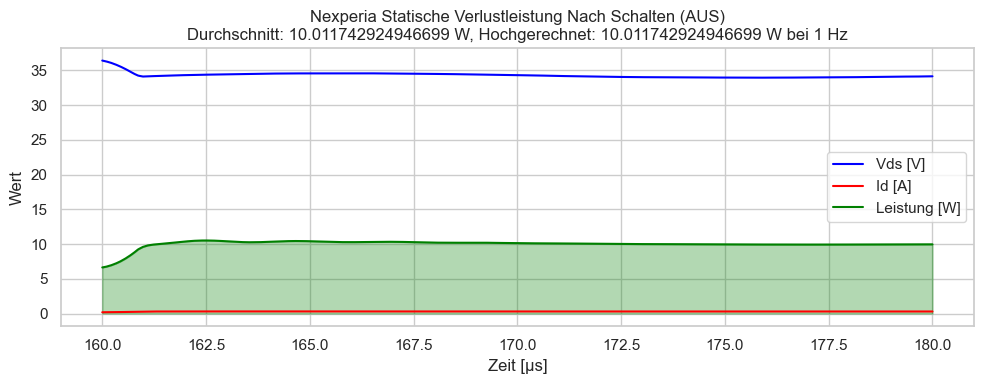


🔧 Analyse statische Verluste (MOSFET AUS): Vishay


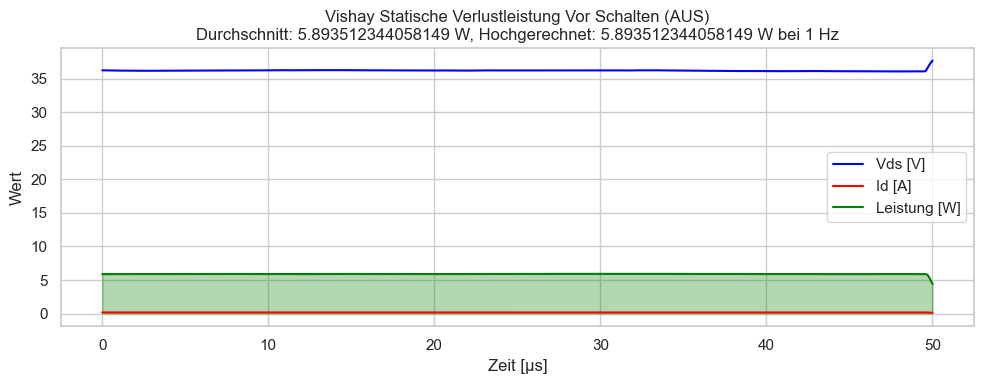

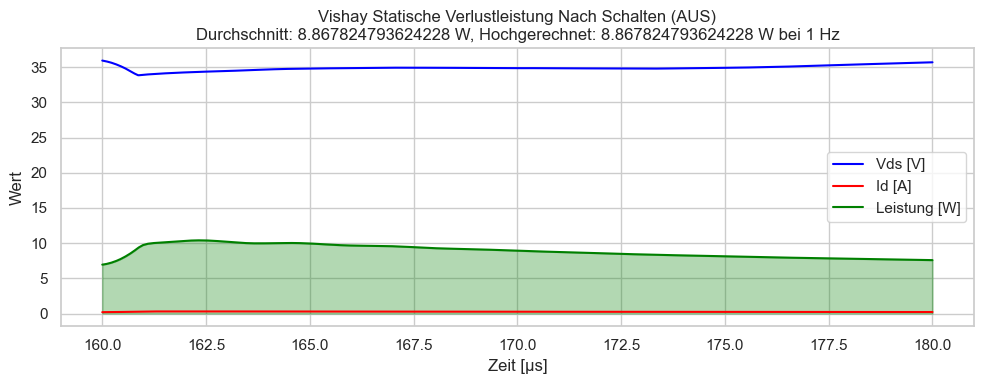


📊 Statische Verlustleistungen (MOSFET AUS):
     MOSFET   Zustand   Leistung_avg_W  Leistung_gesamt_W
0  Nexperia   AUS_VOR   9.478920560840     9.478920560840
1  Nexperia  AUS_NACH  10.011742924947    10.011742924947
2    Vishay   AUS_VOR   5.893512344058     5.893512344058
3    Vishay  AUS_NACH   8.867824793624     8.867824793624


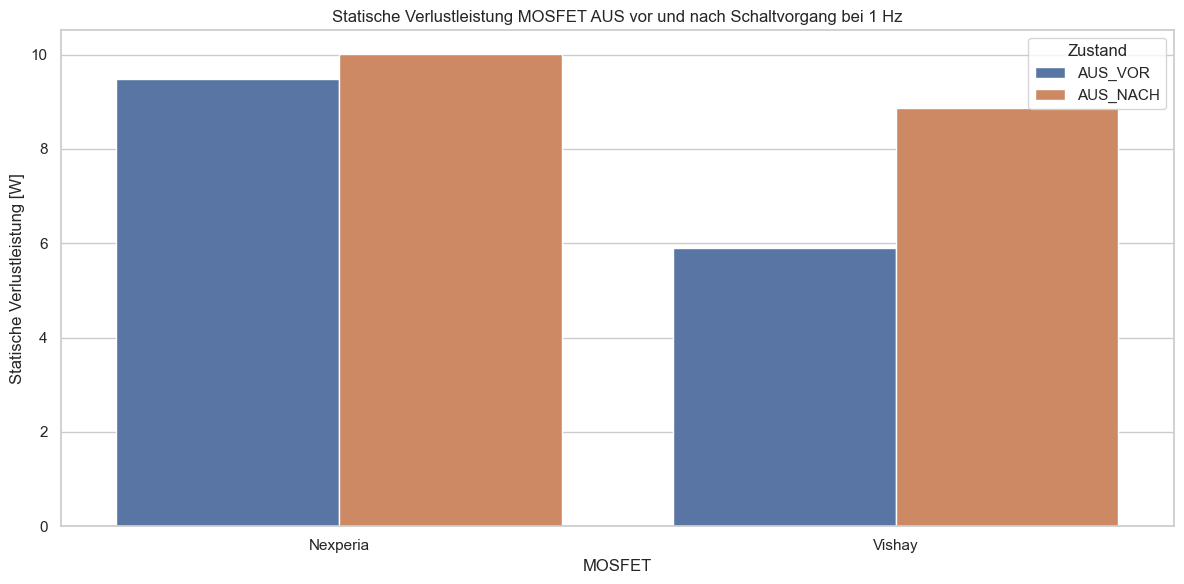

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# ⚙️ Einstellungen
DATA_DIR = "./Messwertebearbeitet/40V"  # Ordner mit den Messdaten
STATIC_OFF_BEFORE_START, STATIC_OFF_BEFORE_END = 0, 50    # vor Schaltzeit, MOSFET AUS [µs]
STATIC_OFF_AFTER_START, STATIC_OFF_AFTER_END = 160, 180   # nach Schaltzeit, MOSFET AUS [µs]
SWITCH_FREQ_HZ = 1                    # Schaltfrequenz (Hz), hier 1 Hz

# Lade und bereite Daten vor
def load_data(filepath):
    df = pd.read_csv(filepath)
    df.columns = [col.strip() for col in df.columns]
    if "Amplitude" in df.columns:
        df = df.rename(columns={"Amplitude": "Ampl"})
    df["Time_us"] = df["Time"] * 1e6
    return df

# Berechnung der statischen Verlustleistung im stabilen Bereich (hochgenau mit float64)
def calculate_static_loss(df_vds, df_id, start_us, end_us, mosfet_name, mode):
    # Interpolation auf gemeinsame Zeitbasis
    interp_vds = interp1d(df_vds["Time_us"], df_vds["Ampl"], kind="linear", fill_value="extrapolate")
    interp_id = interp1d(df_id["Time_us"], df_id["Ampl"], kind="linear", fill_value="extrapolate")
    time_common = np.linspace(start_us, end_us, 1000, dtype=np.float64)  # explizit float64

    vds_vals = interp_vds(time_common).astype(np.float64)
    id_vals = interp_id(time_common).astype(np.float64)

    # Leistung berechnen, negative Werte auf 0 setzen
    power_vals = vds_vals * id_vals
    power_vals = np.where(power_vals < 0, 0.0, power_vals)

    # Durchschnittliche Verlustleistung (hochgenau)
    power_avg_watt = np.mean(power_vals, dtype=np.float64)

    # Leistung auf Schaltfrequenz hochrechnen (bei 1 Hz = gleiches Ergebnis)
    power_total_watt = power_avg_watt * SWITCH_FREQ_HZ

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(time_common, vds_vals, label="Vds [V]", color="blue")
    plt.plot(time_common, id_vals, label="Id [A]", color="red")
    plt.plot(time_common, power_vals, label="Leistung [W]", color="green")
    plt.fill_between(time_common, power_vals, alpha=0.3, color="green")
    plt.title(f"{mosfet_name} Statische Verlustleistung {mode}\n"
              f"Durchschnitt: {power_avg_watt:.15f} W, Hochgerechnet: {power_total_watt:.15f} W bei {SWITCH_FREQ_HZ} Hz")
    plt.xlabel("Zeit [µs]")
    plt.ylabel("Wert")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return power_avg_watt, power_total_watt

# Ergebnisse
results = []

files_c1 = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("C1")])

for file_c1 in files_c1:
    mosfet_name = file_c1[2:].replace(".txt", "")
    file_c2 = f"C2{mosfet_name}.txt"
    path_c1 = os.path.join(DATA_DIR, file_c1)
    path_c2 = os.path.join(DATA_DIR, file_c2)

    if not os.path.exists(path_c2):
        print(f"⚠️ Keine passende Datei für {mosfet_name}, überspringe.")
        continue

    print(f"\n🔧 Analyse statische Verluste (MOSFET AUS): {mosfet_name}")
    df_vds = load_data(path_c1)
    df_id = load_data(path_c2)

    p_off_before_avg, p_off_before_total = calculate_static_loss(
        df_vds, df_id, STATIC_OFF_BEFORE_START, STATIC_OFF_BEFORE_END, mosfet_name, "Vor Schalten (AUS)")
    p_off_after_avg, p_off_after_total = calculate_static_loss(
        df_vds, df_id, STATIC_OFF_AFTER_START, STATIC_OFF_AFTER_END, mosfet_name, "Nach Schalten (AUS)")

    results.append({
        "MOSFET": mosfet_name,
        "Zustand": "AUS_VOR",
        "Leistung_avg_W": p_off_before_avg,
        "Leistung_gesamt_W": p_off_before_total
    })
    results.append({
        "MOSFET": mosfet_name,
        "Zustand": "AUS_NACH",
        "Leistung_avg_W": p_off_after_avg,
        "Leistung_gesamt_W": p_off_after_total
    })

# Zusammenfassung ausgeben mit maximaler Genauigkeit
df_results = pd.DataFrame(results)
pd.set_option('display.precision', 12)  # Ausgabepräzision in DataFrame erhöhen
print("\n📊 Statische Verlustleistungen (MOSFET AUS):")
print(df_results)

# Optional: Balkendiagramm der statischen Verlustleistung
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=df_results, x="MOSFET", y="Leistung_gesamt_W", hue="Zustand")
plt.ylabel("Statische Verlustleistung [W]")
plt.title(f"Statische Verlustleistung MOSFET AUS vor und nach Schaltvorgang bei {SWITCH_FREQ_HZ} Hz")
plt.legend(title="Zustand")
plt.tight_layout()
plt.show()
